# 1 agent and 1 apple - Predicting Euclidian distance between agent and apple using cnn

In [6]:
from pathlib import Path
import pickle
import sys
import os
import random
import numpy as np
import sys
import torch
from tqdm import tqdm
import os
import matplotlib.pyplot as plt

sys.path.append('../')
# Add the root directory to the Python path to find your modules

from models.reward_cnn import RewardCNNDecentralized
from config import MODEL_DIR, GRAPHS_DIR
import torch
from train_scripts.train_centralized_cnn import MODEL_SAVE_PATH
import matplotlib.pyplot as plt
from config import GRAPHS_DIR, OUT_DIR
from tqdm import tqdm


# Helpers

In [ ]:
def generate_distance_dataset(num_samples, width, height):
    """Generates a dataset with num_sample data points that has 1 agent and 1 apple spawned randomly.

    Args:
        num_samples: number of data points to generate
        width: width of the grid
        height: height of the grid

    Returns:
        list[dict] of size num_samples: Each dict has keys state, agent_pos, reward
            state: dict with keys 'agents' and 'apples', each a (height,
            agent_pos: (row, col) tuple of the agent's position,
            reward: float, the Euclidean distance between the agent and the apple
    """
    dataset = []
    for _ in tqdm(range(num_samples), desc=f"Generating {num_samples} samples"):
        # random agent pos and apple pos
        agent_pos = (np.random.randint(0, height), np.random.randint(0, width))
        apple_pos = (np.random.randint(0, height), np.random.randint(0, width))
        
        # Create the state dictionary
        agents_grid = np.zeros((height, width), dtype=np.int8)
        agents_grid[agent_pos] = 1
        
        apples_grid = np.zeros((height, width), dtype=np.int8)
        apples_grid[apple_pos] = 1

        state = {'agents': agents_grid, 'apples': apples_grid}
        
        # Calculate the Euclidean distance as the reward
        reward = np.linalg.norm(np.array(agent_pos) - np.array(apple_pos))
        
        # Append the sample (we only need state and reward for this simple case)
        dataset.append({'state': state, 'agent_pos': agent_pos, 'reward': reward})
        
    return dataset



# Parameters

In [ ]:
# Set a seed for reproducibility!
np.random.seed(42)
random.seed(42)

# Data Parameters
TOTAL_TRAIN_SAMPLES = 100000
TOTAL_TEST_SAMPLES = 20000
WIDTH = 12
HEIGHT = 12

# Training Parameters
NUM_EPOCHS = 10  # Train over the full dataset 10 times
BATCH_SIZE = 64
LEARNING_RATE = 0.001

# Model Parameters
MLP_HIDDEN_FEATURES = 256
MLP_HIDDEN_LAYERS = 2


# Data

In [ ]:
training_data = generate_distance_dataset(TOTAL_TRAIN_SAMPLES, WIDTH, HEIGHT)
testing_data = generate_distance_dataset(TOTAL_TEST_SAMPLES, WIDTH, HEIGHT)

Generating 20000 samples: 100%|██████████| 20000/20000 [00:00<00:00, 88505.82it/s] 


In [5]:
print(f"training_data[0]: {training_data[0]}")
print(f"testing_data[0]: {testing_data[0]}")

training_data[0]: {'state': {'agents': array([[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]], dtype=int8), 'apples': array([[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 0,

In [7]:
model = RewardCNNDecentralized(WIDTH, HEIGHT, LEARNING_RATE, mlp_hidden_features=MLP_HIDDEN_FEATURES, num_mlp_hidden_layers=MLP_HIDDEN_LAYERS)
for epoch in range(NUM_EPOCHS):
    print(f"--- Starting Epoch {epoch+1}/{NUM_EPOCHS} ---")
    # Shuffle the training data at the beginning of each epoch
    random.shuffle(training_data)

    # Use tqdm for a progress bar over the batches
    progress_bar = tqdm(range(0, TOTAL_TRAIN_SAMPLES, BATCH_SIZE), desc=f"Epoch {epoch+1} Training")

    for i in progress_bar:
        # Get a slice of the data for the current mini-batch
        batch = training_data[i : i + BATCH_SIZE]
        
        # Process each sample in the mini-batch
        for sample in batch:
            state = sample['state']
            agent_pos = sample['agent_pos']
            reward = sample['reward']
            
            # Add experience to the model's internal buffer
            model.add_experience_from_raw(state, reward, agent_pos=agent_pos)

        # After processing the whole batch, perform one training step
        loss = model.train_batch()
        
        # Update the progress bar with the latest loss
        if loss is not None:
            progress_bar.set_postfix(loss=f"{loss:.4f}")

--- Starting Epoch 1/10 ---


Epoch 1 Training: 100%|██████████| 1563/1563 [00:07<00:00, 208.17it/s, loss=0.0633]


--- Starting Epoch 2/10 ---


Epoch 2 Training: 100%|██████████| 1563/1563 [00:07<00:00, 212.59it/s, loss=0.0150]


--- Starting Epoch 3/10 ---


...

Epoch 8 Training: 100%|██████████| 1563/1563 [00:07<00:00, 208.55it/s, loss=0.0037]


--- Starting Epoch 9/10 ---


Epoch 9 Training: 100%|██████████| 1563/1563 [00:07<00:00, 211.53it/s, loss=0.0055]


--- Starting Epoch 10/10 ---


Epoch 10 Training: 100%|██████████| 1563/1563 [00:07<00:00, 204.50it/s, loss=0.0059]


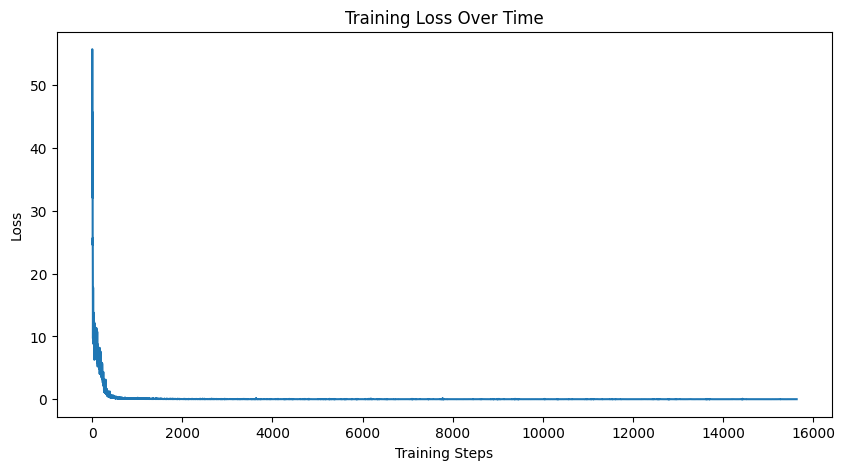

In [8]:
# PLOT TRAINING LOSS
plt.figure(figsize=(10, 5))
plt.plot(model.loss_history, label='Training Loss')
plt.xlabel('Training Steps')
plt.ylabel('Loss')
plt.title('Training Loss Over Time')
plt.show()

# TEST MODEL

In [ ]:
# A good starting point could be 10% of the average distance. Let's use 0.5 for now.
TOLERANCE_OF_ERROR = 0.5 

# --- Step 2: Initialize Variables for Metrics ---
num_correct = 0
total_predictions = len(testing_data)
errors = [] # We'll store all the absolute errors to calculate MAE and RMSE efficiently

# --- Step 3: The Evaluation Loop ---
print("\n--- Starting Evaluation on Test Set ---")
# No need to shuffle the test set.
for sample in tqdm(testing_data, desc="Evaluating"):
    state = sample['state']
    agent_pos = sample['agent_pos']
    true_reward = sample['reward']
    
    # Get the model's prediction. The .item() is important to get a single float.
    predicted_reward = model.get_model_reward_prediction_from_raw(state, agent_pos=agent_pos).item()
    
    # Calculate the absolute error
    error = abs(predicted_reward - true_reward)
    errors.append(error)
    
    # Check if the prediction is within the tolerance for your accuracy metric
    if error < TOLERANCE_OF_ERROR:
        num_correct += 1

accuracy = num_correct / total_predictions

# Standard regression metrics
# Ensure errors list is not empty to avoid division by zero
if errors:
    mean_absolute_error = np.mean(errors)
    root_mean_squared_error = np.sqrt(np.mean(np.square(errors)))
else:
    mean_absolute_error = float('nan')
    root_mean_squared_error = float('nan')


print("\n--- Evaluation Results ---")
print(f"Accuracy (within +/- {TOLERANCE_OF_ERROR} units): {accuracy * 100:.2f}%")
print(f"Mean Absolute Error (MAE): {mean_absolute_error:.4f}")
print(f"Root Mean Squared Error (RMSE): {root_mean_squared_error:.4f}")
print("--------------------------")


--- Starting Evaluation on Test Set ---


Evaluating: 100%|██████████| 20000/20000 [00:12<00:00, 1602.74it/s]


--- Evaluation Results ---
Accuracy (within +/- 0.5 units): 100.00%
Mean Absolute Error (MAE): 0.0740
Root Mean Squared Error (RMSE): 0.0893
--------------------------
